In [76]:
import os
import numpy as np
import csv
from matplotlib import pyplot as plt
import pandas as pd
import itertools
import signal
import time

# Run scheduler with flexible reconfiguration

In [ ]:
def simulate(id_sim, serverModel, restport, envType, mcsVector, mcsAsUniformVar, mcsMinValue, rlc_buffer_size, num_sim, t, vs, qs, gs, s, d, m, speed, fixMcs, fixMcsValue, arGbr, vrGbr, cgGbr, voipGbr, arNum, vrNum, cgNum, voiceNum, arDR, vrDR, cgDR, arFps, vrFps, cgFps, bw, rngRun, numerology, frequency, enableFading, enableShadowing, logging, enableVirtualQueue, scheds):
    for sched in scheds:
        for n in range(0, num_sim):
            if sched == 'DPPA':
                for v in vs:
                    for q in qs:
                        for g in gs:
                            cmd = f"./ns-3-dev/ns3 run nr-sched-o-ran-buildings -- \
                            --appDuration={t} \
                            --schedulerType={sched} \
                            --dppV={v} --dppWeightQ={q} --dppWeightG={g} --enableVirtualQueue={enableVirtualQueue} \
                            --vrGbrDl={vrGbr} --cgGbrDl={cgGbr} --arGbrDl={arGbr} \
                            --scenario={s} --distance={d} --mobility={m} --speed={speed} \
                            --vrUeNum={vrNum} --cgUeNum={cgNum} --arUeNum={arNum} --voiceUeNum={voiceNum} \
                            --arDataRate={arDR} --vrDataRate={vrDR} --cgDataRate={cgDR} \
                            --arFps={arFps} --vrFps={vrFps} --cgFps={cgFps} \
                            --bandwidth={bw} --rngRun={rngRun} --numerology={numerology} --frequency={frequency} \
                            --enableFading={enableFading} --enableShadowing={enableShadowing} --logging={logging} \
                            --rlcBufferSize={rlc_buffer_size} --fixMcs={fixMcs} --fixMcsValue={fixMcsValue} \
                            --mcsVector={mcsVector} --mcsAsUniformVar={mcsAsUniformVar} --mcsMinValue={mcsMinValue} \
                            --server_model={serverModel} --restPort=8000 --envType={envType} > /dev/null 2>&1"
                            os.system(cmd)

                            # Throughput
                            for i in range(1, ueNum+1):
                                cmd = f"cp ns-3-dev/thput_avg_window_id{i}.csv ojcoms_results/{sched}_{envType}/thput_avg_window_id{i}_{bw}.csv"
                                os.system(cmd)
                                print(f'Copied throughput file for UE {i}')
                            # Resource allocation
                            cmd = f"mv ns-3-dev/alpha.txt ojcoms_results/{sched}_{envType}/alpha_{bw}.txt"
                            os.system(cmd)
                            print('Moved resource allocation file')
            else:
                cmd = f"./ns-3-dev/ns3 run nr-sched-o-ran-buildings -- \
                --appDuration={t} \
                --schedulerType={sched} \
                --vrGbrDl={vrGbr} --cgGbrDl={cgGbr} --arGbrDl={arGbr} \
                --scenario={s} --distance={d} --mobility={m} --speed={speed} \
                --vrUeNum={vrNum} --cgUeNum={cgNum} --arUeNum={arNum} --voiceUeNum={voiceNum} \
                --arDataRate={arDR} --vrDataRate={vrDR} --cgDataRate={cgDR} \
                --arFps={arFps} --vrFps={vrFps} --cgFps={cgFps} \
                --bandwidth={bw} --rngRun={rngRun} --numerology={numerology} --frequency={frequency} \
                --enableFading={enableFading} --enableShadowing={enableShadowing} --logging={logging} \
                --rlcBufferSize={rlc_buffer_size} --fixMcs={fixMcs} --fixMcsValue={fixMcsValue} \
                --mcsVector={mcsVector} --mcsAsUniformVar={mcsAsUniformVar} --mcsMinValue={mcsMinValue}"
                os.system(cmd)
                # Throughput
                for i in range(1, ueNum+1):
                    cmd = f"cp ns-3-dev/thput_avg_window_id{i}.csv ojcoms_results/{sched}/thput_avg_window_id{i}_{bw}.csv"
                    os.system(cmd)
                # Resource allocation
                cmd = f"mv ns-3-dev/alpha.txt ojcoms_results/{sched}/alpha_{bw}.txt"
                os.system(cmd)

In [78]:
## Simulation parameters
num_sim = 1
logging = "false"
rngRun = 0
t = 2e5  # ms. App duration
## Scenario
s = "UMa_Buildings"
d = 25
speed = 2  # m/s
m = "true"
numerology = 0
bws = [20e6]
frequency = 6e9
enableFading = "true"
enableShadowing = "false"
## Number of UEs
arNum = 0
vrNum = 2
cgNum = 2
voiceNum = 0
ueNum = arNum + vrNum + cgNum + voiceNum
flowNum = 3*arNum + vrNum + cgNum + voiceNum
## QoS thput requirements
arGbr = 0
vrGbr = 2e6
cgGbr = 4e6
voipGbr = 0
## Traffic parameters
arDR = 20
vrDR = 10
cgDR = 10
arFps = 60
vrFps = 60
cgFps = 60
## Scheduler configuration
vs = [0]
qs = [1]
gs = [1]
enableVirtualQueue = "true"
## RLC buffer size
rlc_buffer_size = 999999999  # Infinite

## MCS configuration
fixMcs = "false"
fixMcsValue = 28
mcsMinValue = 14
mcsAsUniformVar = "false"

serverModel = "DQN"
restport = 8000

In [79]:
## Initialize servers
pid1 = int(os.popen("nohup uvicorn server:app --port=8000 > server1.out & echo $!").read().strip())
print("Server started with PID:", pid1)
time.sleep(10)  # Wait for the server to start

# Clean up
os.system("rm learning_curve*")

# Run simulations for different schedulers
for scheds in [['DPPA_Basic']]:
    print(f'!!! Running scheduler: {scheds}')
    print('Starting simulation...')
    start_time = time.time()
    
    for bw in bws:
        envType = "ISAC"
        if scheds == ['DPPA_ISAC']:
            envType = "ISAC"
            scheds = ['DPPA']
        elif scheds == ['DPPA_Basic']:
            os.kill(pid1, signal.SIGTERM)
            pid1 = int(os.popen("nohup uvicorn server:app --port=8000 > server1.out & echo $!").read().strip())
            time.sleep(10)
            envType = "Basic"
            scheds = ['DPPA']
        
        os.system("> ns-3-dev/sinr_log.txt")
        simulate(0, serverModel, restport, envType, "28,28,28,28,28,28", mcsAsUniformVar, mcsMinValue, 
                rlc_buffer_size, num_sim, t, vs, qs, gs, s, d, m, speed, fixMcs, fixMcsValue, 
                arGbr, vrGbr, cgGbr, voipGbr, arNum, vrNum, cgNum, voiceNum, 
                arDR, vrDR, cgDR, arFps, vrFps, cgFps, bw, rngRun, numerology, 
                frequency, enableFading, enableShadowing, logging, enableVirtualQueue, scheds)
        
    end_time = time.time()
    simulation_time = end_time - start_time
    print(f'Simulation finished in {simulation_time:.2f} seconds ({simulation_time/60:.2f} minutes)')

# Kill server
os.kill(pid1, signal.SIGTERM)
print("Server stopped")

Server started with PID: 288133


INFO:     Started server process [288133]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


!!! Running scheduler: ['DPPA_Basic']
Starting simulation...


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [288133]
INFO:     Started server process [288157]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started server process [288157]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


Copied throughput file for UE 1
Copied throughput file for UE 2
Copied throughput file for UE 3
Copied throughput file for UE 4
Moved resource allocation file
Simulation finished in 158.37 seconds (2.64 minutes)
Server stopped


INFO:     Shutting down


# Average throughput

-- Recopilando datos para scheduler: PF
-- Recopilando datos para scheduler: Qos
-- Recopilando datos para scheduler: DPPA_Basic
-- Recopilando datos para scheduler: DPPA_ISAC


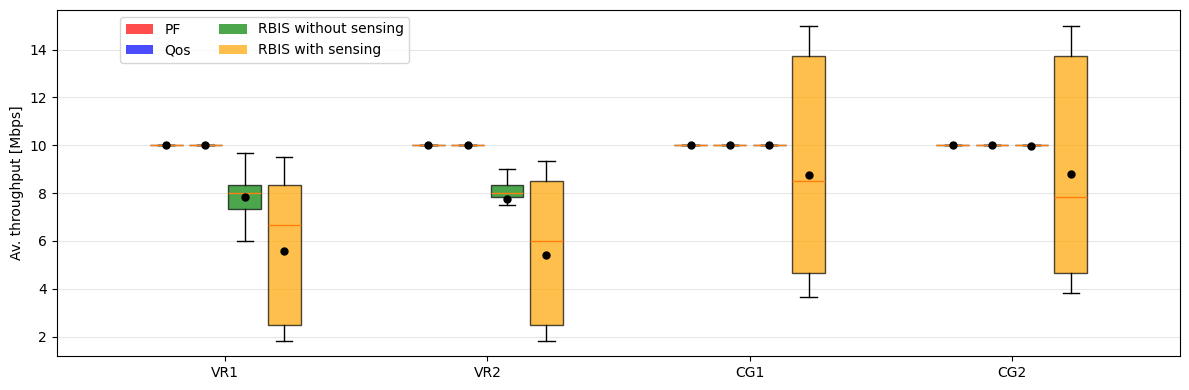

In [81]:
# scheds = ['RR', 'MR', 'PF', 'Qos', 'DPPA_Basic', 'DPPA_ISAC']
scheds = ['PF', 'Qos', 'DPPA_Basic', 'DPPA_ISAC']
bw = 2e7
ueNum = 4
num_sim = 1
sim_id = 0
gfbr_vr = 2
gfbr_cg = 4
folder = 'ojcoms_results'
files = []

# Recopilar datos de throughput para todos los schedulers
all_thput_data = {}
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']  # Colores para cada scheduler

for sched in scheds:
        print(f"-- Recopilando datos para scheduler: {sched}")
        files = []
        for i in range(ueNum):
                files.append(f'{folder}/{sched}/thput_avg_window_id{i+1}_{bw}.csv')

        thput = []
        for f in files:
                thput_ue = []
                with open(f) as File:
                        reader = csv.reader(File, delimiter='\t', quotechar=',',
                                        quoting=csv.QUOTE_MINIMAL)
                        # Si el fichero esta vacio pintar 0
                        if os.stat(f).st_size == 0:
                                thput_ue.append(0)
                        else:
                                next(reader)  # Skip header row
                                for row in reader:
                                        thput_ue.append(float(row[1]))
                # quitar el primer y ultimo valor
                thput_ue = thput_ue[1:-1]
                thput.append(np.array(thput_ue))

        # Quitar el último valor como en el código original
        thput = [np.array(t[:-1]) for t in thput]
        all_thput_data[sched] = thput

# Crear la figura combinada
plt.figure(figsize=(12, 4))

# Configuración para posicionamiento de boxplots
ue_positions = np.arange(1, ueNum + 1) * 1.2  # Posiciones base para cada UE (más separadas)
box_width = 0.15  # Ancho de cada boxplot
spacing = 0.18   # Espaciado entre boxplots

# Crear offsets para cada scheduler
n_scheds = len(scheds)
offsets = np.linspace(-(n_scheds-1)*spacing/2, (n_scheds-1)*spacing/2, n_scheds)

# Plot para cada scheduler
for i, sched in enumerate(scheds):
        for ue_idx in range(ueNum):
                # Posición del boxplot para este UE y scheduler
                position = ue_positions[ue_idx] + offsets[i]
                
                # Crear boxplot
                bp = plt.boxplot(all_thput_data[sched][ue_idx], 
                                positions=[position],
                                widths=box_width,
                                showmeans=True,
                                showfliers=False,
                                meanprops={"marker": "o", "markerfacecolor": "black", 
                                        "markeredgecolor": "black", "markersize": 5},
                                patch_artist=True)  # Necesario para colorear las cajas
                
                # Colorear la caja
                bp['boxes'][0].set_facecolor(colors[i])
                bp['boxes'][0].set_alpha(0.7)

# Configuración de la figura
plt.ylabel("Av. throughput [Mbps]")
# plt.xlabel("UE ID")
# plt.title("Comparación de Throughput por UE y Scheduler")
plt.grid(axis='y', alpha=0.3)

# Configurar xticks
# plt.xticks(ue_positions, [f'UE{i}' for i in range(1, ueNum + 1)])
plt.xticks(ue_positions, ['VR1', 'VR2', 'CG1', 'CG2'])

# Añadir líneas horizontales para GFBR
# plt.axhline(y=gfbr_vr, color='k', linestyle='--', alpha=0.7, label=f'GFBR VR ({gfbr_vr} Mbps)')
# plt.axhline(y=gfbr_cg, color='k', linestyle='--', alpha=0.7, label=f'GFBR CG ({gfbr_cg} Mbps)')

# Crear leyenda personalizada
legend_elements = []
for i, sched in enumerate(scheds):
        if sched == 'DPPA_Basic':
                lab = 'RBIS without sensing'
        elif sched == 'DPPA_ISAC':
                lab = 'RBIS with sensing'
        else:
                lab = sched
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, label=lab))
# legend_elements.append(plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.7, label=f'GFBR VR ({gfbr_vr} Mbps)'))
# legend_elements.append(plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.7, label=f'GFBR CG ({gfbr_cg} Mbps)'))

plt.legend(handles=legend_elements, bbox_to_anchor=(0.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

# Resources usage

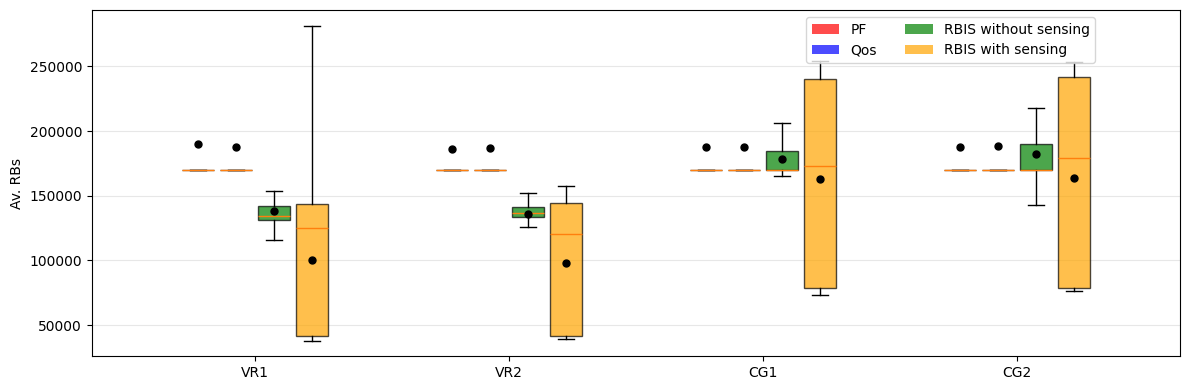

In [82]:
# Recopilar datos de RBs para todos los schedulers
all_rbs_data = {}

for sched in scheds:
    file = f'{folder}/{sched}/alpha_{bw}.txt'
    
    try:
        df = pd.read_csv(file, sep='\t')
        
        # Filtrar hasta time < 1e6
        df_filtered = df[df['time'] < 1e6]
        
        # Preparar datos para este scheduler
        rbs_per_ue = []
        
        for ue_id in range(1, ueNum+1):
            # Obtener todas las asignaciones para este UE
            df_ue = df_filtered[df_filtered['ue'] == ue_id].copy()
            
            if len(df_ue) == 0:
                rbs_per_ue.append(np.array([]))
                continue
            
            # Crear bins de tiempo cada 1000 us
            time_min = df_ue['time'].min()
            time_max = df_ue['time'].max()
            
            # Redondear hacia abajo/arriba para tener bins completos
            time_start = int(time_min // 1000) * 1000
            time_end = int(time_max // 1000 + 1) * 1000
            
            # Crear bins: [0, 1000), [1000, 2000), ...
            bins = np.arange(time_start, time_end, 1000)
            n_bins = len(bins)
            
            # Asignar cada fila a su bin
            df_ue['time_bin'] = pd.cut(df_ue['time'], bins=bins, right=False, labels=False)
            
            # Sumar RBs por bin
            rbs_per_bin = df_ue.groupby('time_bin')['resources'].sum()
            
            # Crear array con ceros para todos los bins
            rbs_array = np.zeros(n_bins - 1)  # -1 porque cut crea n_bins-1 intervalos
            
            # Rellenar con los valores reales donde existan
            for bin_idx, rb_sum in rbs_per_bin.items():
                if not np.isnan(bin_idx):
                    rbs_array[int(bin_idx)] = rb_sum
            
            rbs_per_ue.append(rbs_array)
        
        # Guardar datos para el boxplot combinado
        all_rbs_data[sched] = rbs_per_ue
        
    except FileNotFoundError:
        print(f"File not found: {file}")
        all_rbs_data[sched] = [np.array([]) for _ in range(ueNum)]
    except Exception as e:
        print(f"Error processing {sched}: {e}")
        all_rbs_data[sched] = [np.array([]) for _ in range(ueNum)]

# Crear figura combinada de boxplots para RBs
plt.figure(figsize=(12, 4))

# Configuración para posicionamiento de boxplots (igual que throughput)
ue_positions = np.arange(1, ueNum + 1) * 1.2
box_width = 0.15
spacing = 0.18

# Crear offsets para cada scheduler
n_scheds = len(scheds)
offsets = np.linspace(-(n_scheds-1)*spacing/2, (n_scheds-1)*spacing/2, n_scheds)

# Plot para cada scheduler
for i, sched in enumerate(scheds):
    for ue_idx in range(ueNum):
        # Posición del boxplot para este UE y scheduler
        position = ue_positions[ue_idx] + offsets[i]
        
        # Datos para este UE (incluyen ceros)
        data = all_rbs_data[sched][ue_idx]
        
        if len(data) == 0:
            continue
        
        # Crear boxplot
        bp = plt.boxplot(data, 
                        positions=[position],
                        widths=box_width,
                        showmeans=True,
                        showfliers=False,
                        meanprops={"marker": "o", "markerfacecolor": "black", 
                                  "markeredgecolor": "black", "markersize": 5},
                        patch_artist=True)
        
        # Colorear la caja (usando los mismos colores que throughput)
        bp['boxes'][0].set_facecolor(colors[i])
        bp['boxes'][0].set_alpha(0.7)

# Configuración de la figura
plt.ylabel("Av. RBs")
plt.grid(axis='y', alpha=0.3)

# Configurar xticks
plt.xticks(ue_positions, ['VR1', 'VR2', 'CG1', 'CG2'])

# Crear leyenda personalizada
legend_elements = []
for i, sched in enumerate(scheds):
    if sched == 'DPPA_Basic':
        lab = 'RBIS without sensing'
    elif sched == 'DPPA_ISAC':
        lab = 'RBIS with sensing'
    else:
        lab = sched
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, label=lab))

plt.legend(handles=legend_elements, bbox_to_anchor=(0.65, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

# MCS

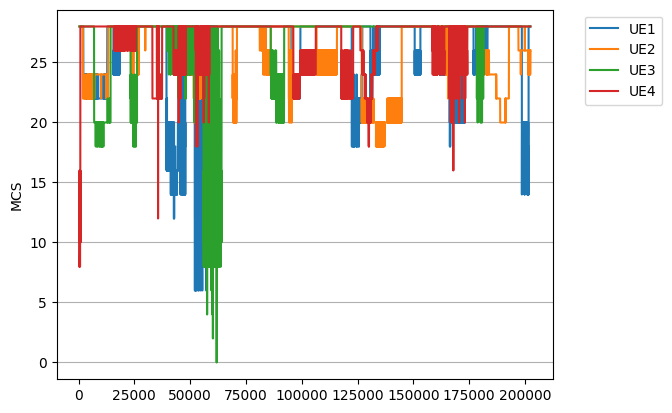

In [83]:
sim_id = 0

for sched in ["DPPA_ISAC"]:
    # A plot of the MCS of every UE during the simulation
    def pintar_mcs(pos, rnti):
        mcsRes = pd.DataFrame()
        # fn = f"ns-3-dev/sim_results/sim_results{sim_id}/{sched}/resources/alpha_{sched}_n{0}.txt"
        fn = f"{folder}/{sched}/alpha_20000000.0.txt"
        df = pd.read_csv(fn, delimiter= '\t')
        # quita los 401 primeros ms
        df = df[df['time'] >= 401]
        mcsRes['t'] = df[df['ue'] == pos]['time']
        mcsRes['t'] = df['time']
        mcsRes['mcs'] = df[df['ue'] == pos]['mcs']
        plt.plot(mcsRes['t'], mcsRes['mcs'], label=f"UE{rnti}")

    plt.figure()
    rnti = 1
    for pos in range(ueNum, 0, -1):
        pintar_mcs(pos, rnti)
        rnti += 1
    # plt.title(f"scenario {s}, distance {d}m, mobility {m}, fixMCS {fixMcs}")
    plt.ylabel("MCS")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');
    plt.grid(axis='y')
    # plt.xlim([2e7, 2.01e7])
    # plt.xlim([7e6, 8e6])
    # plt.ylim([22,30])

# SINR map

Loaded 808004 position points for UEs


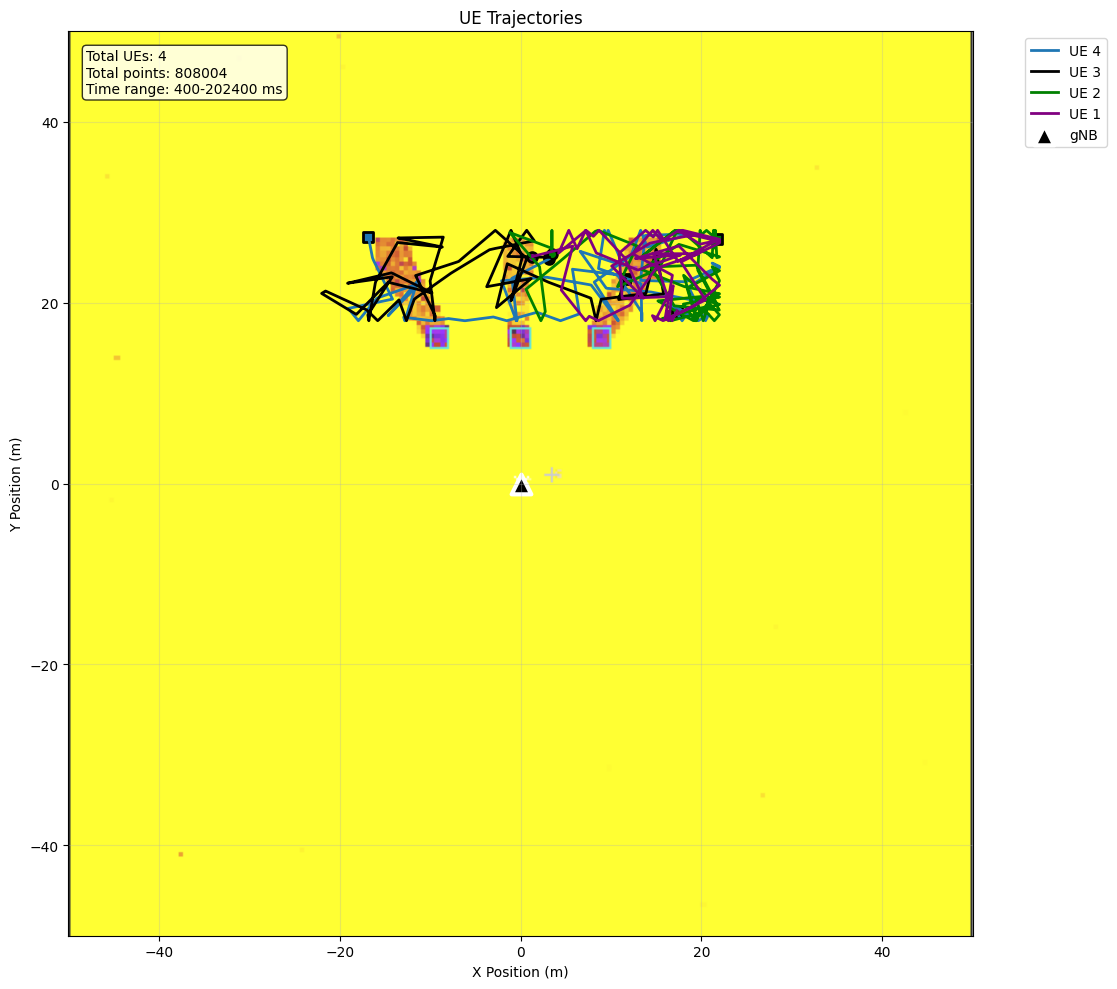

In [84]:
import matplotlib.image as mpimg
from matplotlib.patches import Circle, Rectangle
from matplotlib.transforms import Affine2D
import matplotlib.transforms as transforms
from pathlib import Path

class UETrajectoryPlotter:
    def __init__(self, base_path="./ns-3-dev"):
        self.base_path = Path(base_path)
        self.position_file = self.base_path / "position.txt"
        self.sinr_map_file = self.base_path / "nr-rem-scheduler-sinr.png"
        
        self.map_bounds = {
            'x_min': -50.0,
            'x_max': 50.0,
            'y_min': -50.0,
            'y_max': 50.0
        }
        
        # self.ue_colors = ['tab:blue', 'orange', 'green', 'purple', 'brown', 
        #                   'pink', 'gray', 'olive']
        self.ue_colors = ['tab:blue', 'black', 'green', 'purple', 'brown', 
                          'pink', 'gray', 'olive']
        
        # Obstáculos Circulares
        self.circular_obstacles = [
            # {'center': (-1, 20), 'radius': 1, 'color': 'black', 'alpha': 0.7},
            # {'center': (14, 20), 'radius': 1, 'color': 'black', 'alpha': 0.7},
            # {'center': (-17, 20), 'radius': 1, 'color': 'black', 'alpha': 0.7}
        ]
        self.rectangular_obstacles = [
            {'center': (0, 21), 'width': 12, 'height': 2, 'angle': 90, 'color': 'red', 'alpha': 0.5},
            {'center': (15, 21), 'width': 14, 'height': 2, 'angle': 55, 'color': 'red', 'alpha': 0.5},
            {'center': (-16, 21), 'width': 14, 'height': 2, 'angle': -50, 'color': 'red', 'alpha': 0.5},
        ]
        
    def create_rotated_rectangle(self, ax, center_x, center_y, width, height, angle_deg, **kwargs):
        rect = Rectangle((-width/2, -height/2), width, height, **kwargs)
        t = transforms.Affine2D().rotate_deg(angle_deg).translate(center_x, center_y) + ax.transData
        rect.set_transform(t)
        
        return rect
        
    def load_position_data(self):
        if not self.position_file.exists():
            print(f"Position file not found: {self.position_file}")
            return None
        df = pd.read_csv(self.position_file, sep='\t')
        print(f"Loaded {len(df)} position points for UEs")
        return df

    def load_gnb_positions(self):
        return [(0.0, 0.0)]  # Fixed gNB position

    def load_sinr_map(self):
        if not self.sinr_map_file.exists():
            print(f"SINR map not found: {self.sinr_map_file}")
            return None
        return mpimg.imread(self.sinr_map_file)

    def plot_trajectories_on_sinr_map(self, show_time_evolution=True, time_step=100, show_obstacles=True):
        df = self.load_position_data()
        if df is None:
            return
        sinr_img = self.load_sinr_map()
        gnb_positions = self.load_gnb_positions()
        
        fig, ax = plt.subplots(figsize=(12, 10))

        if sinr_img is not None:
            extent = [self.map_bounds['x_min']-21, self.map_bounds['x_max']+32,
                      self.map_bounds['y_min']-12, self.map_bounds['y_max']+4]
            ax.imshow(sinr_img, extent=extent, aspect='equal', alpha=0.8, origin='upper')

        # Plot UE trajectories
        for i, ue_id in enumerate(sorted(df['ue'].unique(), reverse=True)):
            # if i != 2: continue  # Only show UE x
            color = self.ue_colors[i % len(self.ue_colors)]
            ue_df = df[df['ue'] == ue_id].sort_values('time')
            
            ax.plot(ue_df['x'], ue_df['y'], color=color, linewidth=2, label=f'UE {ue_id}')
            
            # Marcadores inicial y final
            ax.scatter(ue_df.iloc[0]['x'], ue_df.iloc[0]['y'], color=color, s=50,
                       marker='o', edgecolor='black', linewidth=2)
            ax.scatter(ue_df.iloc[-1]['x'], ue_df.iloc[-1]['y'], color=color, s=50,
                       marker='s', edgecolor='black', linewidth=2)
            
            if show_time_evolution:
                time_points = ue_df[::time_step]
                marks = time_points[time_points['time'] % 1e3 == 0]
                # ax.plot(marks['x'], marks['y'], 'x', color='black', markersize=12)

        # gNB
        for i, (x, y) in enumerate(gnb_positions):
            ax.scatter(x, y, color='black', s=200, marker='^', edgecolor='white', linewidth=3, 
                      label='gNB' if i == 0 else "")

        # Add obstacles
        if show_obstacles:
            for i, obs in enumerate(self.circular_obstacles):
                circle = Circle(obs['center'], obs['radius'], 
                              fill=False, color=obs['color'], linewidth=2, 
                              linestyle='--', alpha=obs['alpha'], zorder=20)
                ax.add_patch(circle)
            
            for i, obs in enumerate(self.rectangular_obstacles):
                rect = self.create_rotated_rectangle(
                    ax, obs['center'][0], obs['center'][1], 
                    obs['width'], obs['height'], obs['angle'],
                    facecolor=obs['color'], alpha=obs['alpha'], 
                    edgecolor='darkred', linewidth=2, zorder=15
                )
                ax.add_patch(rect)
                
                label = f"R{i+1}"
                if abs(obs['angle']) > 0.1:  # Solo mostrar ángulo si está rotado
                    label += f"\n{obs['angle']:.0f}°"

        ax.set_xlim(self.map_bounds['x_min'], self.map_bounds['x_max'])
        ax.set_ylim(self.map_bounds['y_min'], self.map_bounds['y_max'])
        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_title("UE Trajectories")
        ax.grid(True, alpha=0.3)

        if df is not None:
            stats_text = f"Total UEs: {df['ue'].nunique()}\nTotal points: {len(df)}\nTime range: {df['time'].min():.0f}-{df['time'].max():.0f} ms"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        # plt.savefig("results/map_with_rotated_obstacles.png", bbox_inches='tight', dpi=300)

        return fig, ax
    
    def plot_obstacles_only(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        
        print("Obstáculos Circulares:")
        for i, obs in enumerate(self.circular_obstacles):
            print(f"  C{i+1}: Centro {obs['center']}, Radio {obs['radius']}m")
            circle = Circle(obs['center'], obs['radius'], 
                          fill=False, color=obs['color'], linewidth=2, 
                          linestyle='--', alpha=obs['alpha'])
            ax.add_patch(circle)
        
        for i, obs in enumerate(self.rectangular_obstacles):
            print(f"  R{i+1}: Centro {obs['center']}, {obs['width']}x{obs['height']}m, Ángulo {obs['angle']}°")
            rect = self.create_rotated_rectangle(
                ax, obs['center'][0], obs['center'][1], 
                obs['width'], obs['height'], obs['angle'],
                facecolor=obs['color'], alpha=obs['alpha'], 
                edgecolor='darkred', linewidth=2
            )
            ax.add_patch(rect)
        
        ax.set_xlim(-30, 30)
        ax.set_ylim(5, 35)
        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_title("Configuración de Obstáculos")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
        
        return fig, ax

plotter = UETrajectoryPlotter(base_path="./ns-3-dev")
fig, ax = plotter.plot_trajectories_on_sinr_map(time_step=100, show_obstacles=False)
plt.show()